In [115]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [169]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import cryptocompare
from sklearn.decomposition import PCA
from datetime import datetime as dt
from datetime import timedelta as td
from scipy.stats import norm
from statsmodels.tsa.arima.model import ARIMA
import warnings
import random
import copy
import sys
from pathlib import Path
import os

plt.rcParams['figure.figsize'] = (16,9)

In [213]:
os.chdir(sys.path[0])
PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))
os.chdir(sys.path[-1])

In [74]:
from src.data import *
from src.risk_cost import *
from src.hyper_optimization import *
from src.wfa import *
from src.performance import *
from src.export import *

## Data

In [2]:
memes_all = ['PEPE', 'MOG', 'FARTCOIN', 'SPX', 'APU', 'GIGA', 'KEYCAT', 'POPCAT', 'BONK', 'WIF', 'SKI', 'MIGGLES', 'doginme', 'TOSHI', 'LOCKIN', 'MICHI', 'BRETT', 'FLOKI', 'FWOG', 'RETARDIO', 'HARRYP']
memes = ['PEPE', 'MOG', 'FARTCOIN', 'SPX', 'GIGA', 'POPCAT', 'BONK', 'WIF', 'TOSHI', 'BRETT', 'FLOKI', 'FWOG', 'HARRYP']
start_date, end_date = dt(2025, 1, 22, 13), dt(2025, 10, 1, 1)

### Cryptocompare

In [ ]:
os.environ['CRYPTOCOMPARE_API_KEY'] = # provide API key here

In [ ]:
cryptocompare.cryptocompare._set_api_key_parameter(os.environ['CRYPTOCOMPARE_API_KEY'])

In [5]:
%%time
df_full, df_full_l, df_full_h = get_data_cryptocompare(start_date, end_date, memes_all)

CPU times: total: 1.81 s
Wall time: 4min 52s


### Binance

In [6]:
memes_bin = {'MOG': '1000000MOGUSDT', 'BONK': '1000BONKUSDC', 'FLOKI': '1000FLOKIUSDT', 'PEPE': '1000PEPEUSDC', 'BRETT': 'BRETTUSDT', 'FARTCOIN': 'FARTCOINUSDT', 'POPCAT': 'POPCATUSDT', 'SPX': 'SPXUSDT', 'WIF': 'WIFUSDC'}

#### Klines

Hours

In [7]:
%%time
for m in memes_bin.keys():
    globals()["df_" + m + "_bin"] = klines_bin(memes_bin[m], start_date, end_date, 'h')

CPU times: total: 797 ms
Wall time: 1min 23s


Minutes

In [8]:
%%time
for m in memes_bin.keys():
    globals()["df_" + m + "_bin_min"] = klines_bin(memes_bin[m], start_date, end_date, 'm')

CPU times: total: 8.97 s
Wall time: 3min 28s


#### Funding rates

In [9]:
%%time
fun_rat_bin = pd.DataFrame()
for m in memes_bin.keys():
    m_fr = get_fun_rat_bin(m, memes_bin[m], start_date, end_date)
    if len(fun_rat_bin) == 0:
        fun_rat_bin = m_fr
    else:
        fun_rat_bin = fun_rat_bin.merge(m_fr, how = "outer", on = "time")
fun_rat_bin = fun_rat_bin.sort_values('time').set_index('time')

CPU times: total: 828 ms
Wall time: 1min 10s


#### Trading fees

In [10]:
fees_bin = {'MOG': 0.0005, 'BONK': 0.0004, 'FLOKI': 0.0005, 'PEPE': 0.0004, 'BRETT': 0.0005, 'FARTCOIN': 0.0005, 'POPCAT': 0.0005, 'SPX': 0.0005, 'WIF': 0.0004}

### ByBit

In [11]:
memes_byb = {'TOSHI': '1000TOSHIUSDT', 'HARRYP': 'HPOS10IUSDT', 'FWOG': 'FWOGUSDT', 'GIGA': 'GIGAUSDT'}

#### Klines

Hours & Minutes

In [12]:
%%time
for m in memes_byb.keys():
    print(m, dt.now())
    globals()["df_" + m + "_byb"], globals()["df_" + m + "_byb_min"] = klines_byb(memes_byb[m], start_date, end_date)

TOSHI 2026-05-20 03:35:32.318742
HARRYP 2026-05-20 03:42:57.844703
FWOG 2026-05-20 03:47:57.011365
GIGA 2026-05-20 03:52:28.556099
CPU times: total: 5min 25s
Wall time: 22min 40s


#### Funding rates

In [13]:
fun_rat_byb = pd.DataFrame()
for m in memes_byb.keys():
    m_fr = read_fun_rat_byb(m, memes_byb[m])
    if len(fun_rat_byb) == 0:
        fun_rat_byb = m_fr
    else:
        fun_rat_byb = fun_rat_byb.merge(m_fr, how = "outer", on = "time")
fun_rat_byb = fun_rat_byb.sort_values('time').set_index('time')

#### Trading fees

In [14]:
fees_byb = {'TOSHI': 0.00055, 'HARRYP': 0.00055, 'FWOG': 0.00055, 'GIGA': 0.00055}

### Preprocessing

In [15]:
for dft, pt in [('df_full', 'close'), ('df_full_l', 'low'), ('df_full_h', 'high')]:
    for m in memes_bin.keys():
        globals()[dft].rename(columns = {m: m + "_spot"}, inplace = True)
        globals()[dft] = globals()[dft].merge(globals()['df_' + m + '_bin'].set_index('time', drop = True).rename(columns = {pt: m})[[m]], how = "left", left_index = True, right_index = True)
    for m in memes_byb.keys():
        globals()[dft].rename(columns = {m: m + "_spot"}, inplace = True)
        globals()[dft] = globals()[dft].merge(globals()['df_' + m + '_byb'].rename(columns = {pt: m})[[m]], how = "left", left_index = True, right_index = True)

In [16]:
df = df_full[memes]
df_l = df_full_l[memes]
df_h = df_full_h[memes]

In [17]:
df_full_r = df_full.pct_change()[1:]
df_r = df.pct_change()[1:]
df_l_r = (df_l / df.shift(1) - 1)[1:]
df_h_r = (df_h / df.shift(1) - 1)[1:]

In [18]:
fun_rat = pd.DataFrame(index = list(df_r.index) + [df_r.index[-1] + td(hours = 1)]).merge(
    fun_rat_bin, how = "left", left_index = True, right_index = True).merge(
    fun_rat_byb, how = "left", left_index = True, right_index = True)[memes]
fun_rat_pred = (~fun_rat.isna() | (fun_rat.isna() & ~fun_rat.shift(-1).isna())) * fun_rat.interpolate()
fun_rat = fun_rat.fillna(0)

In [19]:
fees = pd.DataFrame(index = df_r.index)
for m in memes_bin.keys():
    fees[m] = fees_bin[m]
for m in memes_byb.keys():
    fees[m] = fees_byb[m]
fees = fees[memes]

In [20]:
for m in memes_bin.keys():
    log_rets = np.log(globals()['df_' + m + '_bin_min']['close']).diff()
    globals()['df_' + m + '_bin_min']['real_var'] = log_rets ** 2
    globals()['df_' + m + '_bin_min']['hour'] = globals()['df_' + m + '_bin_min']['time'].dt.floor('h')
for m in memes_byb.keys():
    minutes = [dt(2025, mo, d, h, mi) for mo in range(start_date.month, end_date.month + 1) for d in range(1, (dt(2025, mo + 1, 1) - td(days = 1)).day + 1) for h in range(24) for mi in range(60)]
    zero_rets = pd.DataFrame(pd.Series(0., index = minutes))[1:]
    log_rets = np.log(globals()["df_" + m + "_byb_min"][['close']]).diff()
    log_rets = log_rets.merge(zero_rets, how = "outer", left_index = True, right_index = True).bfill(axis = 1)[['close']]
    log_rets = log_rets.loc[log_rets.index.isin(globals()["df_" + m + "_byb_min"].index)]
    globals()['df_' + m + '_byb_min']['real_var'] = log_rets['close'] ** 2
    globals()['df_' + m + '_byb_min']['hour'] = pd.Series(globals()['df_' + m + '_byb_min'].index, index = globals()['df_' + m + '_byb_min'].index).dt.floor('h')

In [21]:
klines_dict = dict()
klines_dict['bin'] = dict()
klines_dict['byb'] = dict()
klines_dict['bin']['h'] = dict()
klines_dict['bin']['min'] = dict()
klines_dict['byb']['h'] = dict()
klines_dict['byb']['min'] = dict()
for m in memes_bin.keys():
    klines_dict['bin']['h'][m] = globals()['df_' + m + '_bin']
    klines_dict['bin']['min'][m] = globals()['df_' + m + '_bin_min']
for m in memes_byb.keys():
    klines_dict['byb']['h'][m] = globals()['df_' + m + '_byb']
    klines_dict['byb']['min'][m] = globals()['df_' + m + '_byb_min']

### Market Microstructure Models Output

#### Bid-Ask Spread Time Series

In [22]:
df_bas = pd.read_csv('intermediate_output/df_bas_2501_2509.csv').set_index('time')
df_bas.index = pd.to_datetime(df_bas.index)

#### Market Impact Models Coefficients

In [23]:
imp_mod_params = pd.read_csv('intermediate_output/imp_mod_params.csv').set_index('Unnamed: 0')

## Walk-Forward Analysis Run

#### Parameters

In [24]:
is_per = 3 * 30 * 24
oos_per = 30 * 24

In [25]:
cal_int = 30 * 24
recal = 3 * 24
h = 1
lam = 0.94
init_capital = 100000.
lev_cap = 5
risk_av = 10
buf = 0.00025
sl = 1.

In [26]:
varis, cor_mats = covar(cal_int, recal, lam, df_r, h)
fe_bas_pr, fe_bas_o, fe_bas_c, fr_pr, fr_o, fr_c = fix_cost(df, cal_int, fees, df_bas, fun_rat_pred, fun_rat)
im_pr, im_re = var_cost(memes_bin, memes_byb, klines_dict, imp_mod_params, memes, df_r, cal_int)

In [27]:
n_pop = 150
n_ite = 20
b = 0.07
npcd = list(np.arange(10, 16))
npcs_max = 6
npcs_w = 2 / 3
r_th_an = 0.02
n_ret_del = 3
conc_pen_ga = 0.3
bkt_w = 0.6
p_tour = 0.5
n_tour = 5
p_cross = 0.75
p_mut = 0.15
imi_rat = 0.1
args_fix = (df_full_r, cal_int, recal, init_capital, risk_av, varis, fe_bas_pr, fr_pr, im_pr)
memes_fix = ['MOG', 'POPCAT', 'TOSHI', 'FWOG']

In [28]:
n_top = 15
n_nbr = 100
swa_rat = 0.5
main_bkt_w = 0.5

In [29]:
orders = [(1,1), (2,0), (0,2), (2,1), (1,2), (2,2), (3,0), (0,3), (1,0), (0,1)]

In [30]:
ord_sim = dict()
for ord_ma in orders:
    ord_sim[ord_ma] = dict()
    ord_sim[ord_ma]['clo'], ord_sim[ord_ma]['sem'], ord_sim[ord_ma]['far'] = [list() for i in range(3)]
    for ord_ne in orders:
        if ord_ne == ord_ma:
            continue
        if (ord_ne[0] == ord_ma[1]) & (ord_ne[1] == ord_ma[0]):
            ord_sim[ord_ma]['clo'].append(ord_ne)
        elif (ord_ma == (1, 1)) & (ord_ne in [(2, 0), (0, 2)]):
                ord_sim[ord_ma]['clo'].append(ord_ne)
        elif (ord_ma == (2, 2)) & (ord_ne in [(2, 1), (1, 2)]):
                ord_sim[ord_ma]['clo'].append(ord_ne)
        elif ord_ne in [(1, 0), (0, 1)]:
            ord_sim[ord_ma]['far'].append(ord_ne)
        elif ord_ma == (1, 0):
            if ord_ne in [(1, 1), (2, 0)]:
                ord_sim[ord_ma]['sem'].append(ord_ne)
            else:
                ord_sim[ord_ma]['far'].append(ord_ne)
        elif ord_ma == (0, 1):
            if ord_ne in [(1, 1), (0, 2)]:
                ord_sim[ord_ma]['sem'].append(ord_ne)
            else:
                ord_sim[ord_ma]['far'].append(ord_ne)
        else:
            ord_sim[ord_ma]['sem'].append(ord_ne)

In [31]:
main_comb_w, clo_comb_w, sem_comb_w = 0.55, 0.25, 0.15

In [32]:
r_th_an_l, r_th_an_h = 0.005, 0.02
n_top_l, n_top_h = 5, 10

In [33]:
conc_pen_comb2 = 0.2
n_nbrs = 9
comb_drop_th = 0.15

In [34]:
sh_disp_pen_met = "dif pen"
sh_nbr_d_max_ga = 0.3
sh_nbr_d_max_comb2 = 0.35
tp_len_fr_th = 1 / 2
n_top_top = 5
sh_nbr_d_inc = 0.05
sh_dif_pen = 0.5

#### Run

In [51]:
#for wfa_dict in [gens_perf, gens_perf_cache, top_perf, armas_rf_pred, cum_rets_ind, top_combs, joi_tr_perf]:
#    wfa_dict.clear()
#for od in [oos_df.rets_g_oos, oos_df.w_oos, oos_df.port_val_oos]:
#    od.drop(columns = od.columns, inplace = True)
#    od.drop(index = od.index, inplace = True)

In [53]:
%%time
WFA(is_per, oos_per, memes_all, memes, memes_fix, df_full_r, df_l_r, df_h_r, cal_int, recal, h, cor_mats, init_capital, lev_cap, risk_av, varis, buf, sl, fe_bas_pr, fe_bas_o, fe_bas_c, fr_pr, fr_o, fr_c, im_pr, im_re, imp_mod_params['cc_exp'], n_pop, n_ite, b, npcd, npcs_max, npcs_w, r_th_an, n_ret_del, conc_pen_ga, bkt_w, p_tour, n_tour, p_cross, p_mut, imi_rat, n_top, n_nbr, swa_rat, main_bkt_w, orders, ord_sim, main_comb_w, clo_comb_w, sem_comb_w, r_th_an_l, r_th_an_h, n_top_l, n_top_h, conc_pen_comb2, n_nbrs, comb_drop_th, sh_disp_pen_met, sh_nbr_d_max_ga, sh_nbr_d_max_comb2, tp_len_fr_th, n_top_top, sh_nbr_d_inc, sh_dif_pen)

2025-05-22 12:00:00 2026-05-20 21:56:02.943079
goa 2026-05-20 21:56:02.943079
top bkts nbh 2026-05-21 01:58:04.076647
ret pred 2026-05-21 02:08:17.578687
ind tra rets 2026-05-21 03:30:17.004791
joi tra perf 2026-05-21 03:40:16.926616
0 36 2026-05-21 03:40:16.926616
1 30 2026-05-21 04:20:56.750895
oos 2026-05-21 04:49:28.238783

2025-06-21 12:00:00 2026-05-21 04:49:42.000602
goa 2026-05-21 04:49:42.000602
top bkts nbh 2026-05-21 08:32:53.429575
ret pred 2026-05-21 08:44:30.981509
ind tra rets 2026-05-21 10:05:14.410973
joi tra perf 2026-05-21 10:15:18.557992
0 38 2026-05-21 10:15:18.557992
1 31 2026-05-21 11:05:07.421728
2 26 2026-05-21 11:41:55.916802
oos 2026-05-21 12:02:38.598272

2025-07-21 12:00:00 2026-05-21 12:02:52.442779
goa 2026-05-21 12:02:52.462174
top bkts nbh 2026-05-21 15:59:42.121941
ret pred 2026-05-21 16:09:46.543379
ind tra rets 2026-05-21 17:44:47.624764
joi tra perf 2026-05-21 17:55:09.890408
0 34 2026-05-21 17:55:09.890408
1 28 2026-05-21 18:35:53.048726
2 24 2026-

In [84]:
gens_perf_3m_1m, gens_perf_cache_3m_1m, top_perf_3m_1m, armas_rf_pred_3m_1m, cum_rets_ind_3m_1m, top_combs_3m_1m, joi_tr_perf_3m_1m = gens_perf, gens_perf_cache, top_perf, armas_rf_pred, cum_rets_ind, top_combs, joi_tr_perf
rets_g_oos_3m_1m, w_oos_3m_1m, port_val_oos_3m_1m = oos_df.rets_g_oos, oos_df.w_oos, oos_df.port_val_oos
rets_oos_3m_1m = oos_df.rets_g_oos.fillna(0).sum(axis = 1)

#### Save results

In [57]:
lab = "3m_IS_per_1m_OoS_per" 

In [76]:
save_wfa_ho_res(lab, n_ite)

In [83]:
oos_df.rets_g_oos.to_csv('results/WFA_' + lab + '/rets_g_oos.csv')

## Post-Anlysis

### Out-of-Sample Performance

#### Overall Performance

Reward/Risk Metrics

In [117]:
print("Hourly horizon of returns")
print("Sharpe Ratio:", round(sharpe(rets_oos_3m_1m), 3))
print("Sortino Ratio:", round(sortino(rets_oos_3m_1m), 3))
print()
print("Daily horizon of returns")
print("Sharpe Ratio:", round(sharpe(rets_oos_3m_1m, 'd'), 3))
print("Sortino Ratio:", round(sortino(rets_oos_3m_1m, 'd'), 3))

Hourly horizon of returns
Sharpe Ratio: 1.614
Sortino Ratio: 3.775

Daily horizon of returns
Sharpe Ratio: 1.967
Sortino Ratio: 4.127


CAGR and Maximum Drawdown

In [114]:
print("CAGR:", format(cagr(port_val_oos_3m_1m), ".2%"))
print("MDD:", format(mdd(port_val_oos_3m_1m), ".2%"))

CAGR: 5.98%
MDD: 1.47%


Trades and Win Rate

In [212]:
print("Granular level (positions on asset level)")
print("Number of trades:", win_rate(rets_g_oos_3m_1m.fillna(0))[0])
print("Win rate:", format(win_rate(rets_g_oos_3m_1m.fillna(0))[1], ".2%"))
print()
print("Portfolio level (collective positions)")
print("Number of trades:", win_rate(rets_g_oos_3m_1m.fillna(0))[2])
print("Win rate:", format(win_rate(rets_g_oos_3m_1m.fillna(0))[3], ".2%"))

Granular level (positions on asset level)
Number of trades: 1026
Win rate: 49.03%

Portfolio level (collective positions)
Number of trades: 820
Win rate: 49.63%


Historical VaR

In [128]:
print("Daily HVaR(0.99):", format(hvar(port_val_oos_3m_1m)[0], ".2%"))
print("Hourly HVaR(0.99):", format(hvar(port_val_oos_3m_1m)[1], ".2%"))

Daily HVaR(0.99): 0.41%
Hourly HVaR(0.99): 0.05%


Equity Curve

In [173]:
def thousands(x, pos):
    return "$%1.1fk" % (x * 1e-3)
formatter = FuncFormatter(thousands)

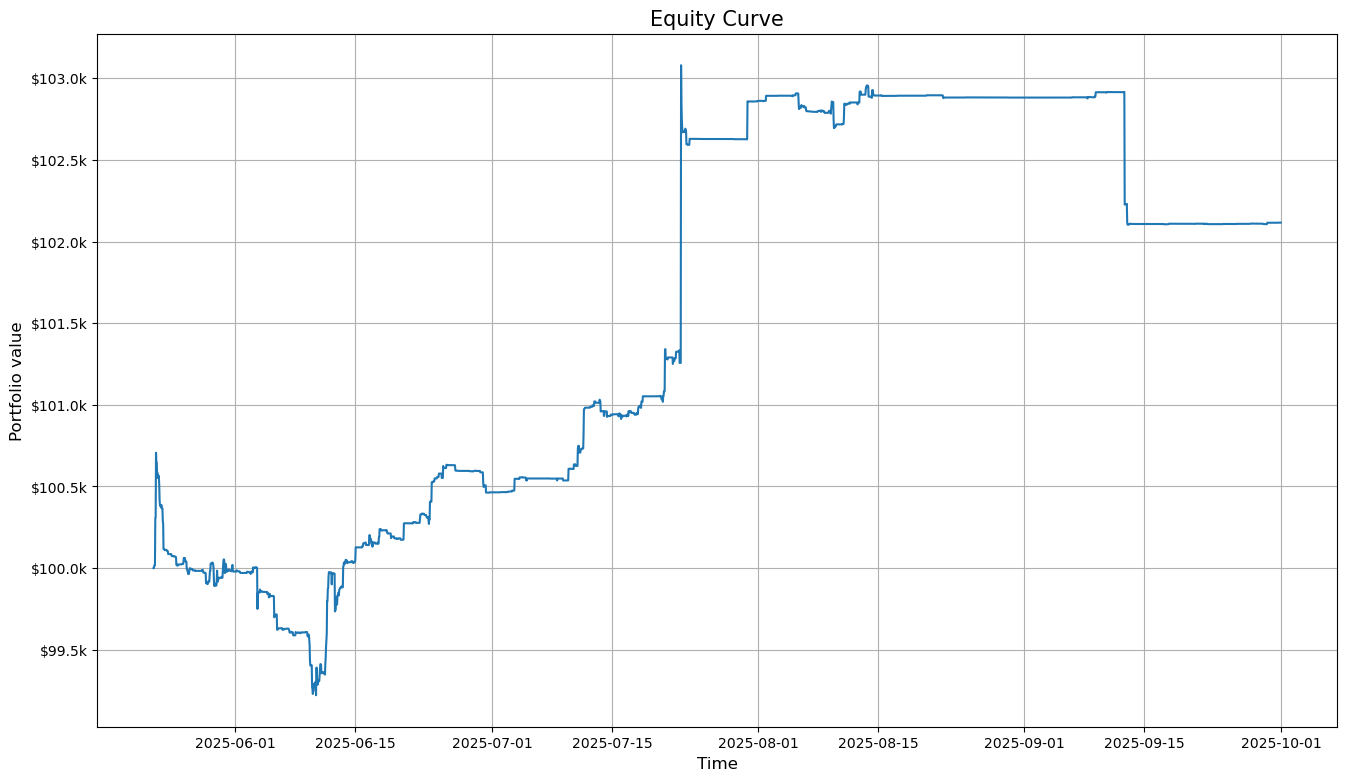

In [178]:
fig, ax = plt.subplots()
ax.plot(port_val_oos_3m_1m)
#ax.set_yscale('log')
ax.yaxis.set_major_formatter(formatter)
plt.title("Equity Curve", size = 15)
plt.xlabel("Time", size = 12)
plt.ylabel("Portfolio value", size = 12)
plt.grid(which = "both")
plt.show()

#### Performance on Different Intervals

Basic metrics for intervals starting with subsequent OoS periods

In [156]:
for i, wf_ti in enumerate(gens_perf_3m_1m.keys()):
    port_val_cut = port_val_oos_3m_1m.loc[wf_ti:] / port_val_oos_3m_1m.loc[wf_ti]
    print(str(i + 1) + '.', wf_ti)
    print("Sharpe:", round(sharpe(port_val_cut.pct_change()[1:]), 3), 
          "Sortino:", round(sortino(port_val_cut.pct_change()[1:]), 3), 
          "CAGR:", format(cagr(port_val_cut), ".2%"),
          "MDD:", format(mdd(port_val_cut), ".3%"))
    print()

1. 2025-05-22 12:00:00
Sharpe: 1.615 Sortino: 3.777 CAGR: 5.99% MDD: 1.474%

2. 2025-06-21 12:00:00
Sharpe: 1.731 Sortino: 4.557 CAGR: 6.77% MDD: 0.947%

3. 2025-07-21 12:00:00
Sharpe: 0.953 Sortino: 2.501 CAGR: 4.23% MDD: 0.947%

4. 2025-08-20 12:00:00
Sharpe: -3.296 Sortino: -3.297 CAGR: -6.46% MDD: 0.790%

5. 2025-09-19 12:00:00
Sharpe: 3.417 Sortino: 7.697 CAGR: 0.20% MDD: 0.004%



Rolling Sharpe Ratio

In [157]:
T = 30 * 24
N = len(rets_oos_3m_1m) - T + 1
sharpe_rol = np.zeros(N)
ny = T / 24 / 365

for i in range(N):   
    rets_i = rets_oos_3m_1m[i:(i + T)]   
    sharpe_rol[i] = sharpe(rets_i)

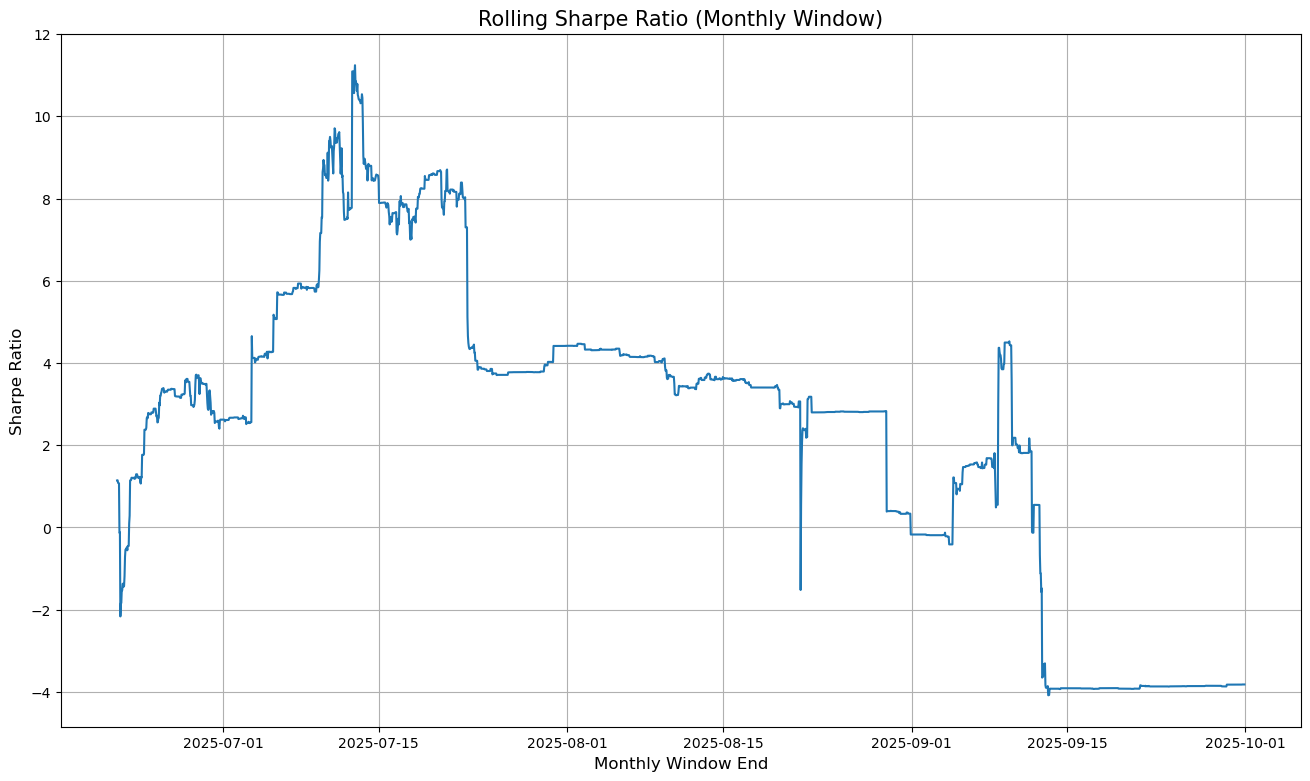

In [162]:
plt.plot(rets_oos_3m_1m.index[(T - 1):], sharpe_rol)
plt.title("Rolling Sharpe Ratio (Monthly Window)", size = 15)
plt.xlabel("Monthly Window End", size = 12)
plt.ylabel("Sharpe Ratio", size = 12)
plt.grid()
plt.show()

### Out-of-Sample Returns Distribution

In [206]:
rnz = rets_oos_3m_1m[rets_oos_3m_1m != 0]
m, sd, sk, kur = rnz.mean(), rnz.std(), rnz.skew(), rnz.kurtosis()

In [200]:
print("Non-zero returns' standardized central moments")
print("Mean: " + format(m, ".4%") + ", Std Dev: " + format(sd, ".3%") + ", Skewness: " + str(round(sk, 2)) + ", Kurtosis: " + str(round(kur, 2)))

Non-zero returns' standardized central moments
Mean: 0.0026%, Std Dev: 0.076%, Skewness: 15.35, Kurtosis: 384.65


In [190]:
pd.DataFrame({'Non-zero returns': rnz.describe().round(5), 'All returns': rets_oos_3m_1m.describe()})

,Non-zero returns,All returns
count,820.00000,3156.000000
mean,0.00003,0.000007
std,0.00076,0.000389
min,-0.00670,-0.006702
25%,-0.00003,0.000000
50%,-0.00000,0.000000
75%,0.00004,0.000000
max,0.01800,0.018004


In [204]:
port_val_d = port_val_oos_3m_1m[(port_val_oos_3m_1m.index.hour == 23) | (port_val_oos_3m_1m.index == port_val_oos_3m_1m.index[0]) | (port_val_oos_3m_1m.index == port_val_oos_3m_1m.index[-1])]
rets_d = np.sqrt(td(days = 1) / port_val_d.index.diff()[1:]) * port_val_d.pct_change()[1:]

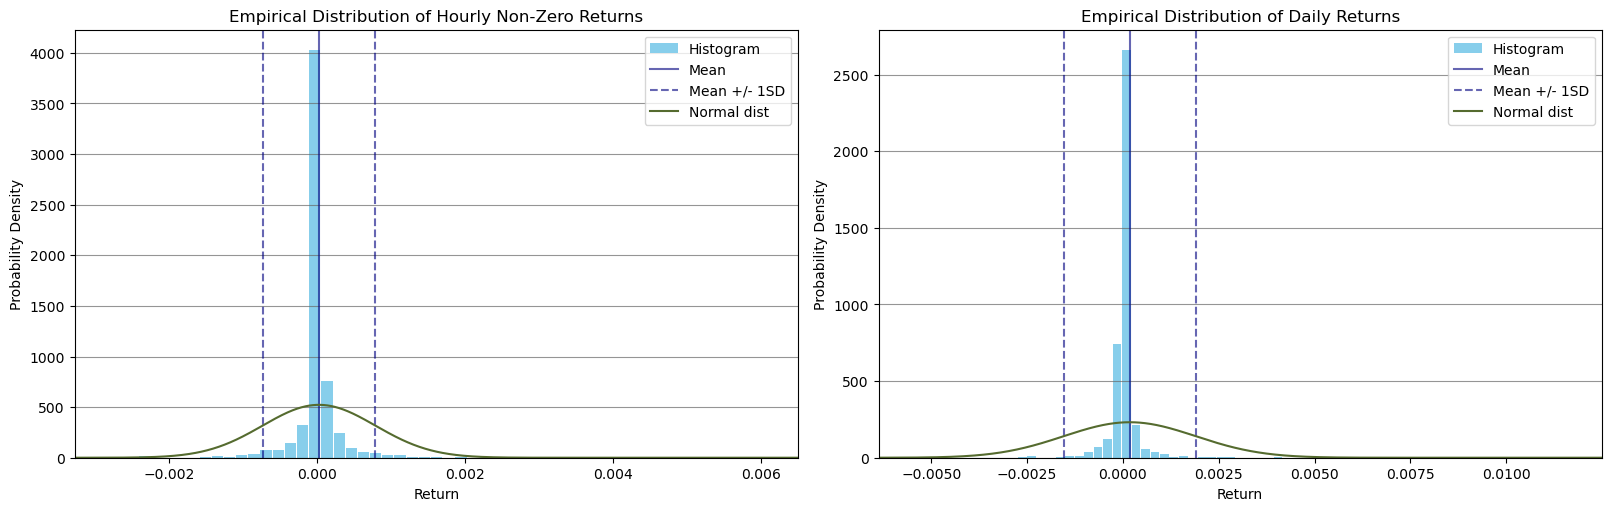

In [211]:
fig, ax = plt.subplots(1, 2, figsize = (16, 5), constrained_layout = True)

for i, rets_i, ret_typ, bins_no in [(0, rnz, "Hourly Non-Zero", 150), (1, rets_d, "Daily", 100)]:
    
    m, sd = rets_i.mean(), rets_i.std()
    ax[i].hist(rnz, bins = bins_no, rwidth = 0.925, density = True, color = 'skyblue', label = "Histogram")
    ax[i].axvline(x = m, color = "navy", alpha = 0.6, label = "Mean")
    ax[i].axvline(x = m + sd, color = "navy", linestyle = "dashed", alpha = 0.6, label = "Mean +/- 1SD")
    ax[i].axvline(x = m - sd, color = "navy", linestyle = "dashed", alpha = 0.6)
    
    x = np.linspace(rets_i.quantile(0.001), rets_i.quantile(0.999), 1000)
    ax[i].plot(x, norm.pdf(x, m, sd), color = "darkolivegreen", label = "Normal dist")
    ax[i].set_xlim([x[0], x[-1]])
    
    ax[i].set_title("Empirical Distribution of " + ret_typ + " Returns", size = 12)
    ax[i].set_xlabel("Return")
    ax[i].set_ylabel("Probability Density")
    ax[i].grid(axis = 'y', alpha = 0.7, color = 'dimgray')
    ax[i].legend()

plt.show()